In [9]:
import random
import json
import matplotlib.colors
import matplotlib.pyplot as plt
import torch
import pandas as pd
import numpy as np
import ase
from tqdm import tqdm
from mace.calculators import mace_mp, mace_off

In [2]:
from franken.autotune import autotune
from franken.data import FrankenAtomsDataset
from franken.config import MaceBackboneConfig, GaussianRFConfig, DatasetConfig, SolverConfig, HPSearchConfig, AutotuneConfig
from franken.data.base import Target
from franken.calculators import FrankenCalculator

In [ ]:
!mkdir FRANKEN

## GNN config

In [ ]:
backbone_id = "mace_mh/1"

gnn_config = MaceBackboneConfig(
    path_or_id=backbone_id,
    interaction_block=2,
)

## Load dataset

In [ ]:
dataset = ase.io.read("DFT/dft.xyz", ":")

for atoms in dataset:
    atoms.center(vacuum=100)
    atoms.set_pbc(True)

ase.io.write("FRANKEN/sampling.xyz", dataset)

In [ ]:
random.shuffle(dataset)
train = dataset[:int(len(dataset)*0.8)]
val = dataset[int(len(dataset)*0.8):]

ase.io.write("FRANKEN/train.xyz", train)
ase.io.write("FRANKEN/val.xyz", val)

In [ ]:
train_dset = FrankenAtomsDataset(
    data_path="FRANKEN/train.xyz",
    split="train",
    gnn_config=gnn_config,
)
train_dl = train_dset.get_dataloader(distributed=False)

val_dset = FrankenAtomsDataset(
    data_path="FRANKEN/val.xyz",
    split="val",
    gnn_config=gnn_config,
)
val_dl = val_dset.get_dataloader(distributed=False)

dataset_cfg = DatasetConfig(
    train_path="FRANKEN/train.xyz",
    val_path="FRANKEN/val.xyz",
)

## Training

In [ ]:
rf_config = GaussianRFConfig(
    num_random_features=512,
    length_scale=HPSearchConfig(values=[1.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0])
)

solver_cfg = SolverConfig(
    l2_penalty=HPSearchConfig(start=-10, stop=-5, num=5, scale='log'),
    force_weight=HPSearchConfig(start=0.01, stop=0.99, num=5, scale='linear'),
)

In [ ]:
autotune_cfg = AutotuneConfig(
    dataset=dataset_cfg,
    solver=solver_cfg,
    backbone=gnn_config,
    rfs=rf_config,
    metrics=["energy_MAE", "forces_MAE"],
    jac_chunk_size='auto',
    run_dir="FRANKEN/results",
)

run_path = autotune(autotune_cfg)

## Analyze

In [3]:
from pathlib import Path
run_path = Path("FRANKEN/results/run_260521_212030_3e0f67c3")

In [4]:
with open(run_path / "log.json", "r") as fh:
    all_logs = json.load(fh)
with open(run_path / "best.json", "r")  as fh:
    best_log = json.load(fh)

In [5]:
best_ls = best_log["hyperparameters"]["random_features"]["length_scale"]
best_l2 = best_log["hyperparameters"]["solver"]["l2_penalty"]
best_fw = best_log["hyperparameters"]["solver"]["force_weight"]
print("Best hyperparameters: ")
print(f"\tLength-scale: {best_ls:.1f}")
print(f"\tL2 penalty: {best_l2:.2e}")
print(f"\tForce-weight: {best_fw:.3f}")

Best hyperparameters: 
	Length-scale: 30.0
	L2 penalty: 1.78e-09
	Force-weight: 0.745


In [6]:
logs_df = pd.json_normalize(all_logs)  # flattens nested dictionaries and converts to DataFrame
logs_df.head()

,checkpoint.hash,checkpoint.rf_weight_id,timings.cov_coeffs,timings.solve,metrics.train.energy_MAE,metrics.train.forces_MAE,metrics.validation.energy_MAE,metrics.validation.forces_MAE,hyperparameters.franken.path_or_id,hyperparameters.franken.family,hyperparameters.franken.interaction_block,hyperparameters.random_features.rf_type,hyperparameters.random_features.num_random_features,hyperparameters.random_features.length_scale,hyperparameters.random_features.use_offset,hyperparameters.random_features.rng_seed,hyperparameters.input_scaler.scale_by_Z,hyperparameters.solver.force_weight,hyperparameters.solver.l2_penalty,hyperparameters.solver.dtype
0,3045e9e0c42fc87bff39fdb33830d864,0,53.224158,0.083144,0.480941,36.915030,0.753436,41.533357,mace_mh/1,mace,2,gaussian,512,1.0,True,1337,True,0.01,1.000000e-10,torch.float64
1,3045e9e0c42fc87bff39fdb33830d864,1,53.224158,0.000934,0.481031,36.908409,0.753510,41.523734,mace_mh/1,mace,2,gaussian,512,1.0,True,1337,True,0.01,1.778279e-09,torch.float64
2,3045e9e0c42fc87bff39fdb33830d864,2,53.224158,0.000848,0.482687,36.817054,0.754886,41.376626,mace_mh/1,mace,2,gaussian,512,1.0,True,1337,True,0.01,3.162278e-08,torch.float64
3,3045e9e0c42fc87bff39fdb33830d864,3,53.224158,0.000841,0.524586,37.772221,0.804591,41.775278,mace_mh/1,mace,2,gaussian,512,1.0,True,1337,True,0.01,5.623413e-07,torch.float64
4,3045e9e0c42fc87bff39fdb33830d864,4,53.224158,0.000832,0.893227,53.082058,1.121949,55.623471,mace_mh/1,mace,2,gaussian,512,1.0,True,1337,True,0.01,1.000000e-05,torch.float64


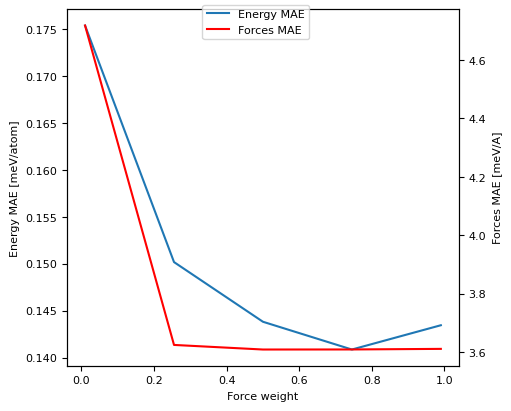

In [29]:
df_fw = logs_df[  # Fix the other two hyperparameters
    (logs_df["hyperparameters.random_features.length_scale"] == best_ls) &
    ((logs_df["hyperparameters.solver.l2_penalty"] - best_l2).abs() < 1e-12)
]
df_fw = df_fw.sort_values("hyperparameters.solver.force_weight")
fig, ax = plt.subplots(figsize=(5,4), layout="constrained")
ax.plot(
    df_fw["hyperparameters.solver.force_weight"],
    df_fw["metrics.validation.energy_MAE"],
    label="Energy MAE"
)
ax2 = ax.twinx()
ax2.plot(
    df_fw["hyperparameters.solver.force_weight"],
    df_fw["metrics.validation.forces_MAE"],
    label="Forces MAE",
    c='r'
)
fig.legend(loc='upper center')
ax.set_xlabel("Force weight")
ax.set_ylabel("Energy MAE [meV/atom]")
ax2.set_ylabel("Forces MAE [meV/A]")
fig.savefig("FRANKEN/force_weight.svg")

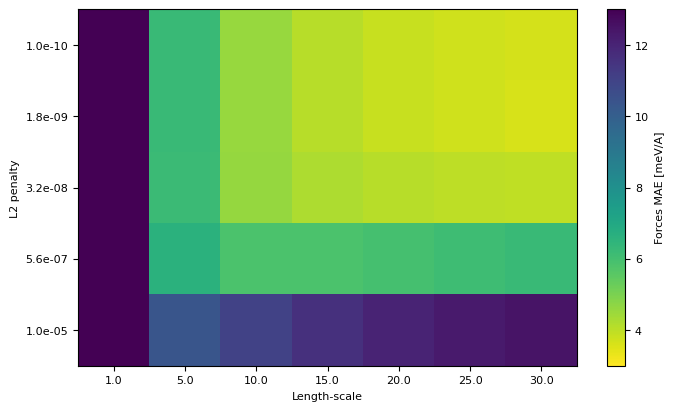

In [23]:
df_ker = logs_df[logs_df["hyperparameters.solver.force_weight"] == best_fw]
fig, ax = plt.subplots(figsize=(7,4), layout="constrained")
pivot = df_ker.pivot_table(
    index="hyperparameters.solver.l2_penalty",
    columns="hyperparameters.random_features.length_scale",
    values="metrics.validation.forces_MAE"
)
im = ax.imshow(pivot, norm=matplotlib.colors.Normalize(vmin=3, vmax=13), cmap="viridis_r")
cb = fig.colorbar(im)
cb.set_label("Forces MAE [meV/A]")
ax.set_xticks(range(len(pivot.columns)), pivot.columns)
ax.set_xlabel("Length-scale")
ax.set_yticks(range(len(pivot.index)), [f"{i:.1e}" for i in pivot.index])
ax.set_ylabel("L2 penalty")
fig.savefig("FRANKEN/ls_l2.svg")

## Zero shot comparison

In [ ]:
targets = []
for i, atoms in enumerate(val):
    targets.append(
        Target(
            energy=torch.tensor(atoms.get_potential_energy()).float(),
            forces=torch.from_numpy(atoms.get_forces()).float(),
        )
    )

In [ ]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"

In [ ]:
# zeroshot_maceoff = mace_off(model="https://github.com/ACEsuit/mace-off/raw/refs/heads/main/mace_off24/MACE-OFF24_medium.model", default_dtype="float64")

In [ ]:
zeroshot_macemp = mace_mp(backbone_id, default_dtype="float64")

zeroshot_predictions = []
for atom_data in tqdm(val, desc="Predicting energies and forces"):
    zeroshot_macemp.calculate(atoms=atom_data)
    predictions = Target(
        torch.tensor(zeroshot_macemp.results["energy"]),
        torch.from_numpy(zeroshot_macemp.results["forces"])
    )
    zeroshot_predictions.append(predictions)
constant_difference = torch.tensor(all_pred_energy).mean() - torch.tensor(all_target_energy).mean()


all_pred_energy = []
all_target_energy = []
for i, atom_data in enumerate(val):
    targets = Target(
        energy=torch.tensor(atom_data.get_potential_energy()).float(),
        forces=torch.from_numpy(atom_data.get_forces()).float(),
    )
    predictions = zeroshot_predictions[i]
    all_target_energy.append(targets.energy)
    all_pred_energy.append(predictions.energy)

zeroshot_energy_mae = franken.metrics.init_metric("energy_MAE", device="cpu")
zeroshot_forces_mae = franken.metrics.init_metric("forces_MAE", device="cpu")
    zeroshot_predictions[i] = Target(
        energy=zeroshot_predictions[i].energy - constant_difference,
        forces=zeroshot_predictions[i].forces
    )
    zeroshot_energy_mae.update(zeroshot_predictions[i], targets)
    zeroshot_forces_mae.update(zeroshot_predictions[i], targets)
zeroshot_energy_mae = zeroshot_energy_mae.compute().item()
zeroshot_forces_mae = zeroshot_forces_mae.compute().item()

print(f"Zero-shot MACE-MP0 energy error = {zeroshot_energy_mae:.2f} meV/atom")
print(f"Zero-shot MACE-MP0 forces error = {zeroshot_forces_mae:.2f} meV/Angstrom")


In [ ]:
model = FrankenCalculator("FRANKEN/results/run_260518_140939_bd40575e/best_ckpt.pt")

energy_mae = franken.metrics.init_metric("energy_MAE", device=device)
forces_mae = franken.metrics.init_metric("forces_MAE", device=device)
franken_predictions = []
for atom_data, targets in tqdm(val_dl, desc="Predicting energies and forces"):
    # Move the data to the GPU
    atom_data = atom_data.to(device=device)
    targets = targets.to(device=device)
    pred_e, pred_f = model.energy_and_forces(
        atom_data,
        weights=weights,
        forces_mode="torch.autograd",
        add_energy_shift=True
    )
    predictions = Target(pred_e, pred_f)
    energy_mae.update(predictions, targets)
    forces_mae.update(predictions, targets)
    franken_predictions.append(predictions.to(device="cpu"))
energy_mae = energy_mae.compute().item()
forces_mae = forces_mae.compute().item()

print(f"Energy MAE = {energy_mae:.2f} meV/atom")
print(f"Forces MAE = {forces_mae:.2f} meV/Angstrom")

In [ ]:
energy_mae = franken.metrics.init_metric("energy_MAE", device="cpu")
forces_mae = franken.metrics.init_metric("forces_MAE", device="cpu")
errors = {
    "energy": {
        "franken": [],
        "zeroshot": []
    },
    "forces": {
        "franken": [],
        "zeroshot": []
    }
}
for i, atom_data in enumerate(val):
    targets = Target(
        energy=torch.tensor(atom_data.get_potential_energy()).float(),
        forces=torch.from_numpy(atom_data.get_forces()).float(),
    )
    energy_mae.update(zeroshot_predictions[i], targets)
    errors["energy"]["zeroshot"].append(energy_mae.compute(reset=True).item())
    energy_mae.update(franken_predictions[i], targets)
    errors["energy"]["franken"].append(energy_mae.compute(reset=True).item())
    forces_mae.update(zeroshot_predictions[i], targets)
    errors["forces"]["zeroshot"].append(forces_mae.compute(reset=True).item())
    forces_mae.update(franken_predictions[i], targets)
    errors["forces"]["franken"].append(forces_mae.compute(reset=True).item())



In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 4))
data = (
    [errors["energy"]["zeroshot"], errors["energy"]["franken"]],
    [errors["forces"]["zeroshot"], errors["forces"]["franken"]]
)
colors = ['#5975A4', '#CC8963']
for i, ax in enumerate(axs):
    quartile1, medians, quartile3 = np.percentile(data[i], [25, 50, 75], axis=1)
    vp = ax.violinplot(data[i], showextrema=False)
    for j, pc in enumerate(vp['bodies']):
        pc.set_facecolor(colors[j])
        pc.set_edgecolor('black')
        pc.set_alpha(0.9)
    ax.scatter([1, 2], medians, marker='o', color='white', s=30, zorder=3)
    ax.vlines([1, 2], quartile1, quartile3, color='k', linestyle='-', lw=5)
    ax.vlines([1, 2], np.min(data[i], axis=1), np.max(data[i], axis=1), color='k', lw=1)
    ax.set_xticks([1, 2], ["Zero shot", "Franken"])
axs[0].set_ylabel("Energy MAE (mev/atom)")
axs[0].set_title("Energy errors")
axs[1].set_ylabel("Forces MAE (meV/Å)")
axs[1].set_title("Force errors")